# Assignement 1

importation des librairies ...

In [2]:
import torch
import matplotlib.pyplot as plt
import pickle
import numpy as np
import os
import copy

In [3]:
# Récupère le dossier où se trouve ton notebook
base_dir = os.getcwd()

## Exercice 1

In [4]:
def loadBatch(filename):
    cifar_dir = 'cifar-10-batches-py/'
    with open(cifar_dir + filename, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')

    # Extract the image data and cast to float from the dict dictionary
    X = dict[b'data'].astype(np.float64) / 255.0
    X = X.transpose()
    # one-hot representation of the label for each image
    y = list(dict[b'labels'])
    Y = np.eye(10, dtype=X.dtype)[y].T

    return X, Y, y

## 2. Chargé les données 

dans cette section je vais construire une fonction pour affiché les images. mais surtout j'aimerai pouvoir récupéré un set de base pour pouvoir entrainer mon réseau de neuronne


In [5]:
def print_imgs_batch(X, ni = 5):
    nn = X.shape[1]
    # Reshape each image from a column vector to a 3d array
    X_im = X.reshape((32, 32, 3, nn), order='F')
    X_im = np.transpose(X_im, (1, 0, 2, 3))
    # Display the first 5 images
    fig, axs = plt.subplots(1, 5, figsize=(10, 5))
    for i in range(ni):
        axs[i].imshow(X_im[:, :, :, i])
        axs[i].axis('off')


In [6]:
trainX, trainY, train_y = loadBatch("data_batch_1")
valX, valY, val_y = loadBatch("data_batch_2")
testX, testY, test_y = loadBatch("test_batch")

d, n = trainX.shape
mean_trainX = np.mean(trainX, axis=1).reshape(d, 1)
std_trainX = np.std(trainX, axis=1).reshape(d, 1)

trainX = (trainX - mean_trainX) / std_trainX
valX = (valX - mean_trainX) / std_trainX
testX = (testX - mean_trainX) / std_trainX

/var/folders/p5/q_svw6p15zg9rpq42m98_sf40000gn/T/ipykernel_37709/2923868985.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


## 3. Initialization des poids

In [7]:
W = np.empty((trainY.shape[0],trainX.shape[0]),dtype=float)
b = np.empty((trainY.shape[0],1),dtype=float)
#print(W.shape) -> verify dimensions
#print(b.shape)
init_net= {'W': W, 'b': b}

def random_assignment(network):
    """
    permet de pouvoir initier des points de manière randoms en gardant un certain range
    """
    rng = np.random.default_rng()
    # get the BitGenerator used by default_rng
    BitGen = type(rng.bit_generator)
    # use the state from a fresh bit generator
    seed = 42
    rng.bit_generator.state = BitGen(seed).state
    network['W'] = .01*rng.standard_normal(size = network['W'].shape)
    network['b'] = np.zeros(network['b'].shape)

## 4. Foward pass

dans cette partie, nous allons utiliser les formules de calculs des données avec les poids. c'est l'équation de base pour obtenir un résultat a partir d'une donnée.


In [9]:
def softMax(s):
    exp_s = np.exp(s)
    return exp_s/ np.sum(exp_s, axis=0, keepdims=True)

def ApplyNetwork(X,network):
    s = network['W'] @ X + network['b']
    return softMax(s)

P = ApplyNetwork(trainX,init_net)

## 5. loss et Cost

comme nous le savons le loss et cost permet de d'évaluer l'erreur de prédiction de notre modèle et nous ajoutons aussi un cout de chaque erreur calculer en utilisant +2\*$\lambda$\*W


In [11]:
def ComputeLoss(P, y):
    y = np.array(y)
    N = P.shape[1]
    return -np.mean(np.log(P[y, np.arange(N)]))

def ComputeCost(P, y, network, lam):
    loss = ComputeLoss(P, y)
    return loss + lam * np.sum(network['W'] ** 2)

L = ComputeLoss(P,train_y)

## 6. Calculer la précision de notre modèle

Nous allons tout simplement faire une moyenne de prédiction en fonction des résultats réel $y$ et ceux prédit par notre modèle $P$

In [18]:
def ComputeAccuracy(P, y):
    pred = np.argmax(P, axis=0)
    y = np.array(y)
    return np.mean(pred == y)

acc = ComputeAccuracy(P,train_y)


## 7. BackPropagation

Nous exploitons la backpropagation pour pouvoir obtenir le gradient de nos poids $W$ ainsi que celui de $b$ pour pouvoir ensuite update notre modèle !!

In [20]:
def BackwardPass(X, Y, P, network, lam):
    G = P - Y ## erreur de sortie du modèle P --> ces probabilité et Y les one hot fix ==> c est le gradient de la loss
    N = P.shape[1]
    grads = {}
    grads['W'] = 1/N * G @ X.T + 2*lam*network['W']
    grads['b'] = (1/N) * np.sum(G, axis=1, keepdims=True) ## axis=1 pour sommer sur les colonnes
    return grads

## 8 L'entrainement

la fonction mère qui permet de pouvoir entrainer notre modèle. cette fonction utilise des batches qui sont simplement la division de notre data d'entrainement pour pouvoir entrainer notre modèle sur de petit morceaux de dataSet. l'objectif de faire ceci est d'optimsier l'apprentissage et augmenter les chances au modèle de trouver des patern. 

In [21]:
def miniBatchGD(X, Y, y, valX, val_y, GDparams, init_net, seed):
    trained_net = copy.deepcopy(init_net)

    n_batch = GDparams['n_batch']
    eta = GDparams['eta']
    n_epochs = GDparams['n_epochs']
    lam = GDparams['lam']
    n = X.shape[1]

    rng = np.random.default_rng(seed)

    train_losses = []
    val_losses = []
    train_costs = []
    val_costs = []

    for epoch in range(n_epochs):
        perm = rng.permutation(n) ## rendre aléatoire la répartition des données pour mélanger les mini_batches
        X_shuffled = X[:, perm]
        Y_shuffled = Y[:, perm]

        for j in range(n // n_batch):
            j_start = j * n_batch
            j_end = (j + 1) * n_batch
            inds = slice(j_start, j_end)

            Xbatch = X_shuffled[:, inds]
            Ybatch = Y_shuffled[:, inds]
            ## fowrard ( donc le modèle évalue )
            Pbatch = ApplyNetwork(Xbatch, trained_net)
            ## Backpropagation pour récupéré les gradiants ##
            grads = BackwardPass(Xbatch, Ybatch, Pbatch, trained_net, lam)

            ## update des poids W et b
            trained_net['W'] = trained_net['W'] - eta * grads['W']
            trained_net['b'] = trained_net['b'] - eta * grads['b']

        ## sauvegarde de tout les calculs fait ##
        trainP = ApplyNetwork(X, trained_net)
        valP = ApplyNetwork(valX, trained_net)

        train_loss = ComputeLoss(trainP, y)
        val_loss = ComputeLoss(valP, val_y)
        train_cost = ComputeCost(trainP, y, trained_net, lam)
        val_cost = ComputeCost(valP, val_y, trained_net, lam)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_costs.append(train_cost)
        val_costs.append(val_cost)

        print(f"Epoch {epoch + 1}/{n_epochs}: train loss = {train_loss:.6f}, val loss = {val_loss:.6f}, train cost = {train_cost:.6f}, val cost = {val_cost:.6f}")

    history = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'train_cost': train_costs,
        'val_cost': val_costs,
    }

    return trained_net, history

## 9. observation des résultats:

In [26]:
## initalisation ##
GDparams = {}
GDparams['n_batch'] = 100
GDparams['eta'] = .001
GDparams['n_epochs'] = 40 ## nombre de fois que je vais traverser les n_batch
GDparams['lam'] = 0.1
seed = 42
W = np.empty((trainY.shape[0],trainX.shape[0]),dtype=float)
b = np.empty((trainY.shape[0],1),dtype=float)
init_net= {'W': W, 'b': b}
random_assignment(init_net)

## TRAINING ##

trained_net, history = miniBatchGD(trainX, trainY, train_y, valX, val_y, GDparams, init_net, seed)
 

Epoch 1/40: train loss = 1.972574, val loss = 2.001612, train cost = 2.270653, val cost = 2.299691
Epoch 2/40: train loss = 1.893640, val loss = 1.935534, train cost = 2.181607, val cost = 2.223500
Epoch 3/40: train loss = 1.849266, val loss = 1.900984, train cost = 2.127782, val cost = 2.179500
Epoch 4/40: train loss = 1.821327, val loss = 1.880572, train cost = 2.090815, val cost = 2.150059
Epoch 5/40: train loss = 1.799872, val loss = 1.865782, train cost = 2.060752, val cost = 2.126662
Epoch 6/40: train loss = 1.782760, val loss = 1.853947, train cost = 2.035432, val cost = 2.106619
Epoch 7/40: train loss = 1.770258, val loss = 1.847876, train cost = 2.015106, val cost = 2.092724
Epoch 8/40: train loss = 1.757218, val loss = 1.838352, train cost = 1.994555, val cost = 2.075689
Epoch 9/40: train loss = 1.747995, val loss = 1.833162, train cost = 1.978162, val cost = 2.063330
Epoch 10/40: train loss = 1.739082, val loss = 1.827924, train cost = 1.962447, val cost = 2.051289
Epoch 11/

In [45]:
## test de notre réseau
## TEST ## 
testP = ApplyNetwork(testX, trained_net)
test_acc = ComputeAccuracy(testP, test_y)


In [68]:
def print_imgs_with_pred(X, P, index_imgs, max_imgs=5):
    label_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
    ]
    index_imgs = list(index_imgs)[:max_imgs]
    nn = X.shape[1]

    # Reshape each image from a column vector to a 3D array
    X_im = X.reshape((32, 32, 3, nn), order='F')
    X_im = np.transpose(X_im, (1, 0, 2, 3))

    n_imgs = len(index_imgs)
    n_cols = 3
    n_rows = int(np.ceil(n_imgs / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    axs = np.array(axs).reshape(n_rows, n_cols)

    for k, img_idx in enumerate(index_imgs):
        row = k // n_cols
        col = k % n_cols
        pred = np.argmax(P[:, img_idx])
        pred_name = label_names[pred]

        axs[row, col].imshow(X_im[:, :, :, img_idx])
        axs[row, col].set_title(f"img {img_idx}\npred = {pred_name}")
        axs[row, col].axis('off')

    # cacher les cases vides
    for k in range(n_imgs, n_rows * n_cols):
        row = k // n_cols
        col = k % n_cols
        axs[row, col].axis('off')

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0344312220847587..2.248182575238828].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8733465853402589..2.1441503897458425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8244782494785972..2.0942264379086004].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.52326938716389..1.4536100663875726].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0621039939535213..2.2269927781041003].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7358846814612965..2.242298892936373].
Clipping input data to the

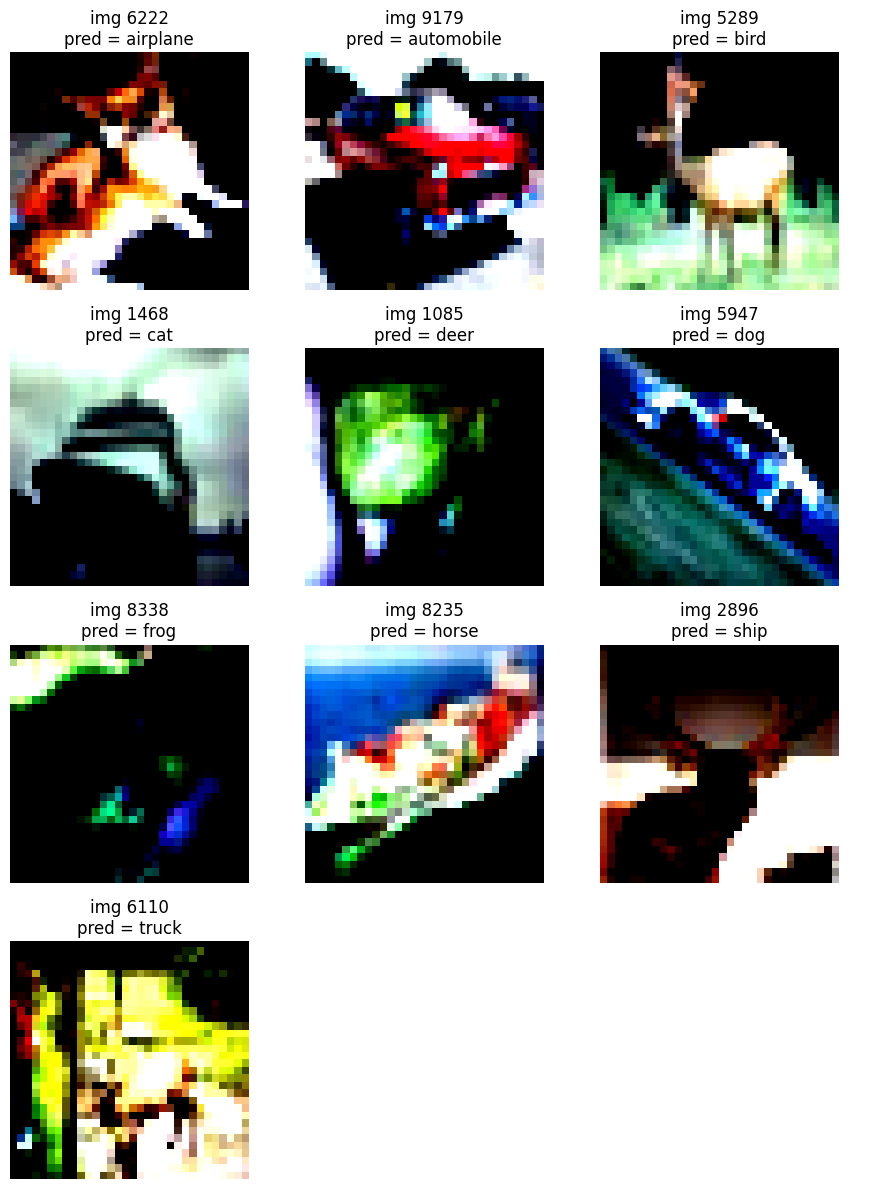

In [69]:
print_imgs_with_pred(trainX,testP,np.argmax(testP, axis=1),10)